<a href="https://colab.research.google.com/github/arshadraza1205/Data-analysis/blob/main/Sales_Performance_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [9]:
import pandas as pd

# Load data with appropriate encoding to handle special characters
df = pd.read_csv("superstore_final_dataset (1).csv", encoding="windows-1252")

# Convert dates to datetime format
df["Order_Date"] = pd.to_datetime(df["Order_Date"], errors="coerce", dayfirst=True)
df["Ship_Date"] = pd.to_datetime(df["Ship_Date"], errors="coerce", dayfirst=True)

# Check for missing values and remove duplicates
print("Missing values:\n", df.isnull().sum())
df = df.drop_duplicates()

# View the first 5 rows
df.head()

Missing values:
 Row_ID            0
Order_ID          0
Order_Date        0
Ship_Date         0
Ship_Mode         0
Customer_ID       0
Customer_Name     0
Segment           0
Country           0
City              0
State             0
Postal_Code      11
Region            0
Product_ID        0
Category          0
Sub_Category      0
Product_Name      0
Sales             0
dtype: int64


,Row_ID,Order_ID,Order_Date,Ship_Date,Ship_Mode,Customer_ID,Customer_Name,Segment,Country,City,State,Postal_Code,Region,Product_ID,Category,Sub_Category,Product_Name,Sales
0,1,CA-2017-152156,2017-11-08,2017-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600
1,2,CA-2017-152156,2017-11-08,2017-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400
2,3,CA-2017-138688,2017-06-12,2017-06-16,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,California,90036.0,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200
3,4,US-2016-108966,2016-10-11,2016-10-18,Standard Class,SO-20335,Sean O Donnel,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775
4,5,US-2016-108966,2016-10-11,2016-10-18,Standard Class,SO-20335,Sean O Donnel,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold N Roll Cart System,22.3680


In [10]:
# Calculate Total Revenue
total_revenue = df["Sales"].sum()

# Calculate Total Orders
total_orders = df["Order_ID"].nunique()

# Calculate Average Order Value (AOV)
average_order_value = total_revenue / total_orders

# Calculate Total Customers
total_customers = df["Customer_ID"].nunique()

# Display the calculated KPIs
print(f"Total Revenue: ${total_revenue:,.2f}")
print(f"Total Unique Orders: {total_orders}")
print(f"Average Order Value (AOV): ${average_order_value:,.2f}")
print(f"Total Unique Customers: {total_customers}")

Total Revenue: $2,261,536.78
Total Unique Orders: 4922
Average Order Value (AOV): $459.48
Total Unique Customers: 793


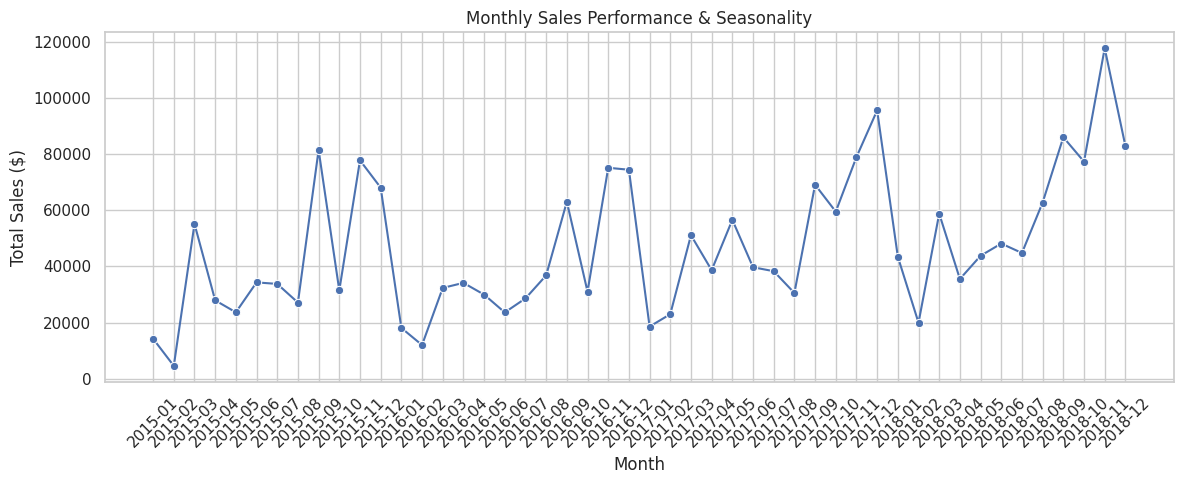

/tmp/ipykernel_3870/1574459768.py:24: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df, x="Segment", y="Sales", estimator=sum, errorbar=None, palette="Set2")


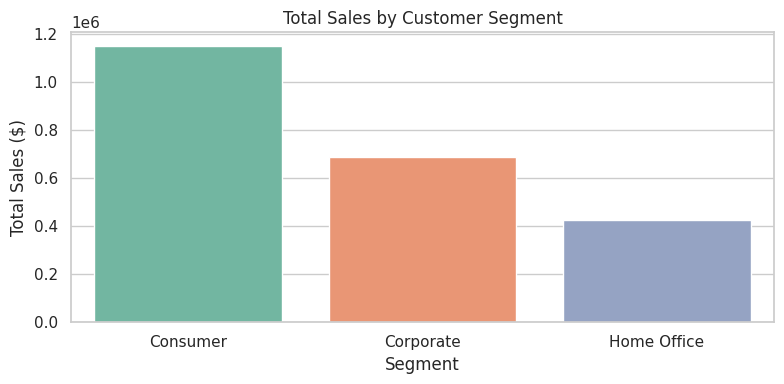

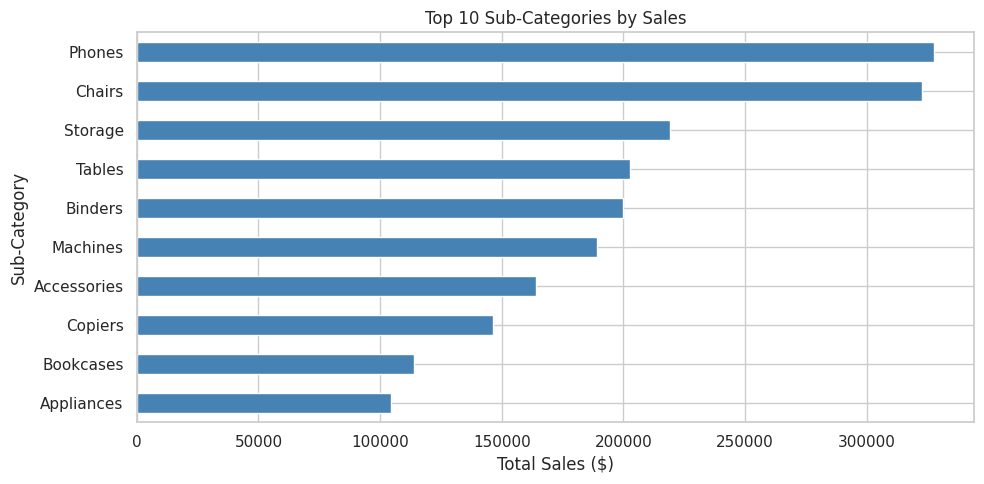

In [11]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set the visual style for the plots
sns.set_theme(style="whitegrid")

# 1. Monthly Sales Trend (Seasonality)
# Creating a new column for Year-Month
df["Order_Month"] = df["Order_Date"].dt.to_period("M")
monthly_sales = df.groupby("Order_Month")["Sales"].sum().reset_index()
monthly_sales["Order_Month"] = monthly_sales["Order_Month"].astype(str)

plt.figure(figsize=(12, 5))
sns.lineplot(data=monthly_sales, x="Order_Month", y="Sales", marker="o", color="b")
plt.xticks(rotation=45)
plt.title("Monthly Sales Performance & Seasonality")
plt.xlabel("Month")
plt.ylabel("Total Sales ($)")
plt.tight_layout()
plt.show()

# 2. Total Sales by Customer Segment
plt.figure(figsize=(8, 4))
sns.barplot(data=df, x="Segment", y="Sales", estimator=sum, errorbar=None, palette="Set2")
plt.title("Total Sales by Customer Segment")
plt.xlabel("Segment")
plt.ylabel("Total Sales ($)")
plt.tight_layout()
plt.show()

# 3. Top 10 Best-Selling Sub-Categories
top_products = df.groupby("Sub_Category")["Sales"].sum().sort_values(ascending=False).head(10)

plt.figure(figsize=(10, 5))
top_products.plot(kind="barh", color="steelblue").invert_yaxis()
plt.title("Top 10 Sub-Categories by Sales")
plt.xlabel("Total Sales ($)")
plt.ylabel("Sub-Category")
plt.tight_layout()
plt.show()

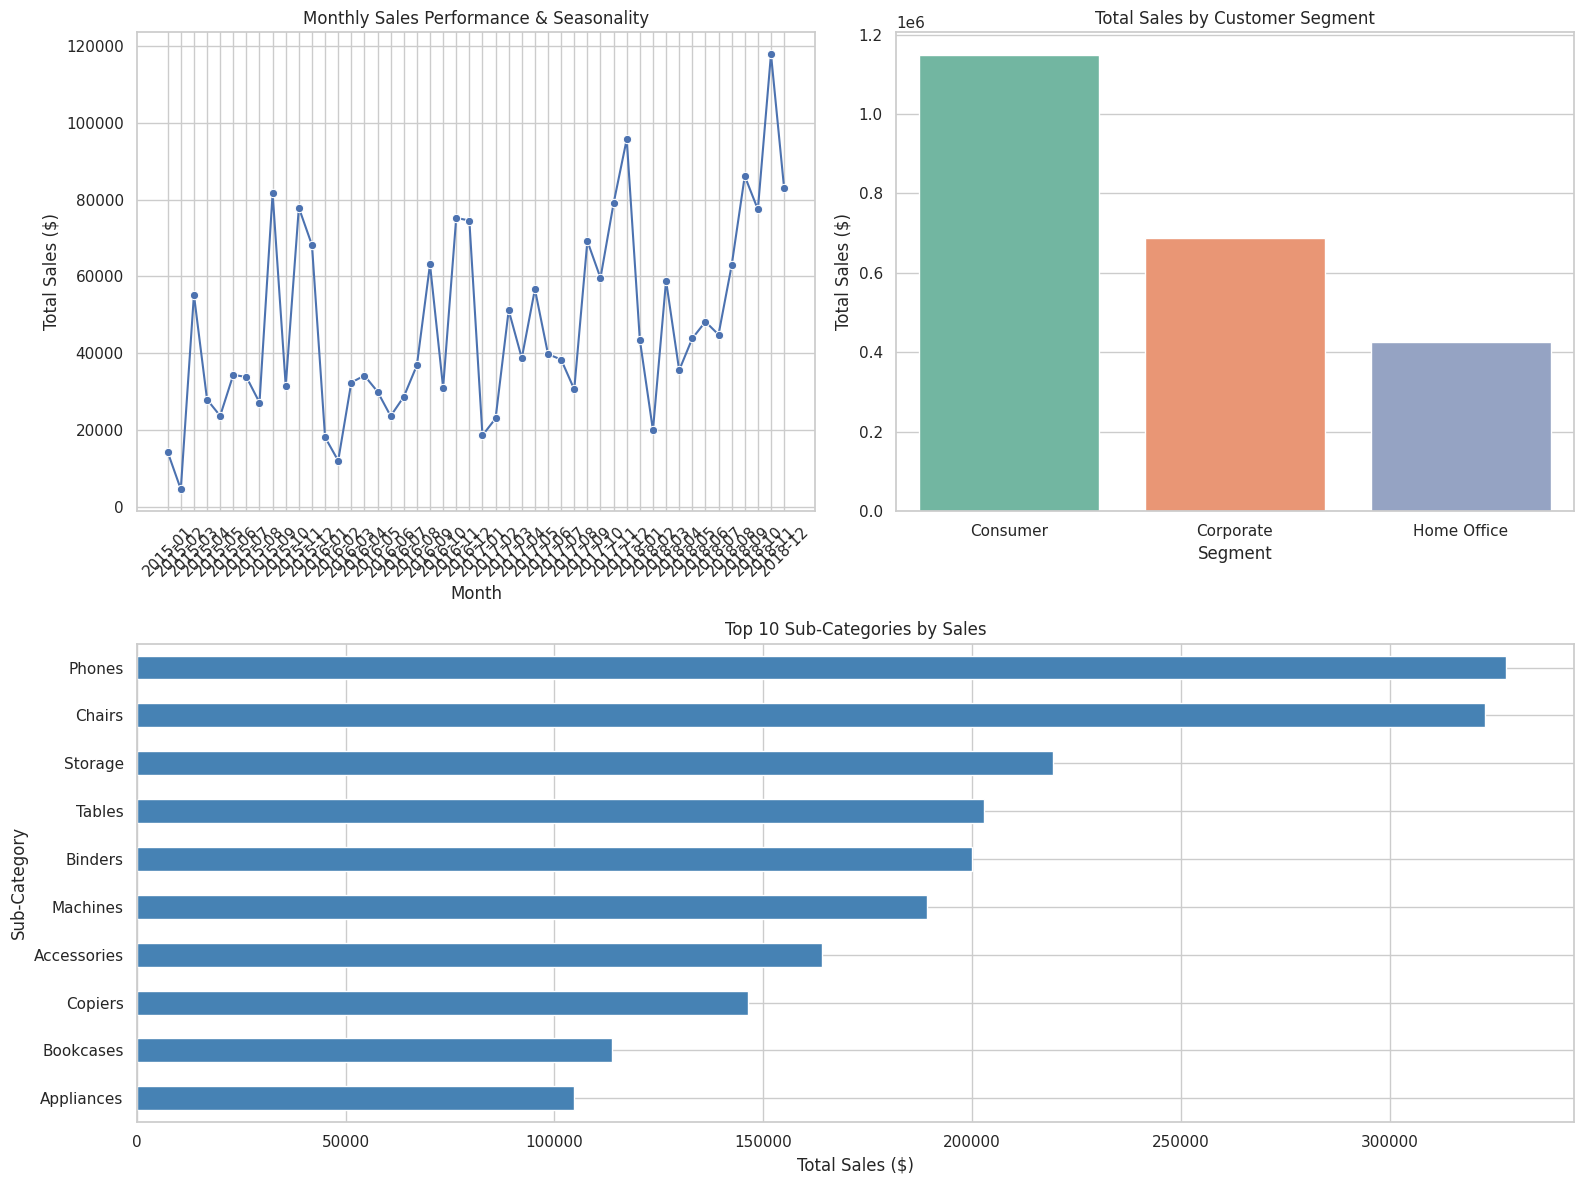

In [12]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

# Create a single large figure for the dashboard
plt.figure(figsize=(16, 12))

# 1. Monthly Sales Trend (Top Left)
plt.subplot(2, 2, 1)
sns.lineplot(data=monthly_sales, x="Order_Month", y="Sales", marker="o", color="b")
plt.xticks(rotation=45)
plt.title("Monthly Sales Performance & Seasonality")
plt.xlabel("Month")
plt.ylabel("Total Sales ($)")

# 2. Total Sales by Customer Segment (Top Right)
plt.subplot(2, 2, 2)
# Added hue="Segment" and legend=False to resolve the seaborn warning
sns.barplot(data=df, x="Segment", y="Sales", estimator=sum, errorbar=None, hue="Segment", palette="Set2", legend=False)
plt.title("Total Sales by Customer Segment")
plt.xlabel("Segment")
plt.ylabel("Total Sales ($)")

# 3. Top 10 Best-Selling Sub-Categories (Bottom row, spanning full width)
plt.subplot(2, 1, 2)
top_products.plot(kind="barh", color="steelblue").invert_yaxis()
plt.title("Top 10 Sub-Categories by Sales")
plt.xlabel("Total Sales ($)")
plt.ylabel("Sub-Category")

# Adjust layout to prevent overlap, save as one image, and display
plt.tight_layout()
plt.savefig("task2_combined_dashboard.png", dpi=300, bbox_inches="tight")
plt.show()